In [1]:
import pandas as pd

df = pd.read_csv("reddit_master_dataset.csv")

print(df.shape)
df.head()

(24194, 7)


,subreddit,title,score,comments,created_utc,url,text
0,MachineLearning,[P] Bypassing CoreML to natively train a 110M ...,NaN,NaN,NaN,NaN,NaN
1,MachineLearning,[D] A mathematical proof from an anonymous Kor...,NaN,NaN,NaN,NaN,NaN
2,MachineLearning,[P] I built an open cognitive architecture for...,NaN,NaN,NaN,NaN,NaN
3,MachineLearning,[D] Working on a photo-based calorie tracker app,NaN,NaN,NaN,NaN,NaN
4,MachineLearning,[D] Intel Core Ultra 7 265K vs AMD Ryzen 7 780...,NaN,NaN,NaN,NaN,NaN


In [2]:
# Check missing values

df.isna().sum()

subreddit          5
title              0
score           8683
comments        8683
created_utc     8683
url             8683
text           11811
dtype: int64

In [3]:
# Remove rows without subreddit
df = df.dropna(subset=["subreddit"])

# Fill numeric columns
df["score"] = df["score"].fillna(0)
df["comments"] = df["comments"].fillna(0)

# Fill text columns
df["text"] = df["text"].fillna("")
df["url"] = df["url"].fillna("")

# Fill timestamp
df["created_utc"] = df["created_utc"].fillna(0)

# Check again
df.isna().sum()

subreddit      0
title          0
score          0
comments       0
created_utc    0
url            0
text           0
dtype: int64

In [4]:
print("Total posts:", len(df))
print("Unique subreddits:", df["subreddit"].nunique())
print("Average score:", round(df["score"].mean(),2))
print("Average comments:", round(df["comments"].mean(),2))

Total posts: 24189
Unique subreddits: 33
Average score: 107.45
Average comments: 17.29


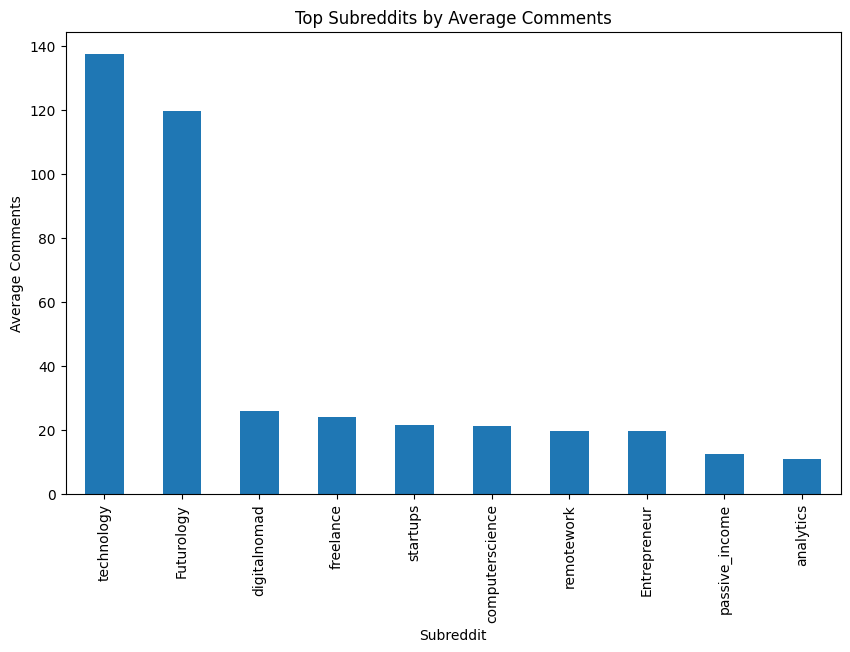

In [6]:
avg_comments = df.groupby("subreddit")["comments"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
avg_comments.plot(kind="bar")

plt.title("Top Subreddits by Average Comments")
plt.xlabel("Subreddit")
plt.ylabel("Average Comments")

plt.show()

In [11]:
#Extract Problem Statement


df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")


problem_patterns = [
    "i wish there was",
    "why is there no",
    "does anyone know a tool",
    "i need a tool",
    "is there a tool",
    "i hate how",
    "there should be",
    "someone should build"
]

def detect_problem(text):
    text = text.lower()
    return any(p in text for p in problem_patterns)

df["problem_post"] = df["content"].apply(detect_problem)

problem_posts = df[df["problem_post"]]

print("Problem posts found:", len(problem_posts))

problem_posts[["subreddit","title"]].head(20)# Topic Classification
ai_keywords = [
    "ai","gpt","llm","machine learning",
    "neural","model","automation"
]

startup_keywords = [
    "startup","founder","saas",
    "product","launch","build"
]

marketing_keywords = [
    "marketing","growth","seo",
    "content","branding","customer",
    "advertising"
]

df["ai_post"] = df["title"].str.lower().apply(
    lambda x: any(word in x for word in ai_keywords)
)

df["startup_post"] = df["title"].str.lower().apply(
    lambda x: any(word in x for word in startup_keywords)
)

df["marketing_post"] = df["title"].str.lower().apply(
    lambda x: any(word in x for word in marketing_keywords)
)

print("AI posts:", df["ai_post"].sum())
print("Startup posts:", df["startup_post"].sum())
print("Marketing posts:", df["marketing_post"].sum())

Problem posts found: 16
AI posts: 5969
Startup posts: 2863
Marketing posts: 606


Total posts: 24194
Unique subreddits: 33

Posts discussing products: 9759
After removing news posts: 8657

Product Markets:
market
Other                  5757
Analytics Tools         779
Developer Tools         755
SaaS Products           401
Freelancer Tools        338
AI Tools                331
Creator Economy         238
Marketing Tools          56
Community Platforms       2
Name: count, dtype: int64


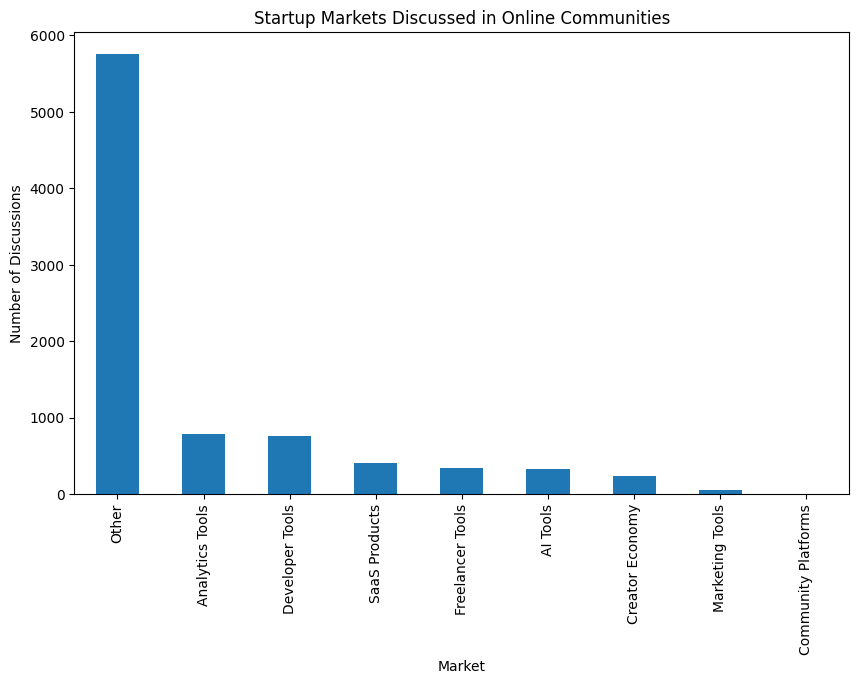


Engagement by market:
                         score   comments
market                                   
Other                79.307429  18.782702
AI Tools             60.773663  19.415638
Developer Tools      29.367213  16.237705
Creator Economy      28.286325  19.350427
Freelancer Tools     21.017910  20.167164
Analytics Tools      15.155172  10.054377
SaaS Products         9.076655  13.519164
Marketing Tools       5.080000  15.000000
Community Platforms   1.000000   4.000000

Top product-related posts:
                                                   title   subreddit    score  \
17978  CEOs are hugely expensive. Why not automate th...  Futurology  49299.0   
16631  Claude hits No. 1 on App Store as ChatGPT user...  technology  38923.0   
16936  Discord cuts ties with Peter Thiel-backed veri...  technology  37999.0   
18268  "What trillion-dollar problem is Al trying to ...  Futurology  27012.0   
16796  Burger King will use AI to check if employees ...  technology  22318.0   
1

In [16]:
# ===============================
# STARTUP OPPORTUNITY ANALYSIS
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("reddit_master_dataset.csv")

print("Total posts:", len(df))
print("Unique subreddits:", df["subreddit"].nunique())

# ------------------------
# COMBINE TEXT
# ------------------------

df["content"] = (
    df["title"].fillna("") + " " + df["text"].fillna("")
).str.lower()

# ------------------------
# PRODUCT DISCUSSION FILTER
# ------------------------

product_words = [
"tool","platform","software","app","automation",
"dashboard","analytics","saas","plugin",
"api","marketplace","service","crm","bot","agent"
]

df["product_post"] = df["content"].apply(
    lambda x: any(word in x for word in product_words)
)

product_posts = df[df["product_post"]].copy()

print("\nPosts discussing products:", len(product_posts))

# ------------------------
# REMOVE TECH NEWS BIAS
# ------------------------

news_words = [
"tesla","apple","amazon","google",
"military","government","law","china"
]

product_posts = product_posts[
~product_posts["content"].str.contains("|".join(news_words))
]

print("After removing news posts:", len(product_posts))

# ------------------------
# BUSINESS PRODUCT MARKETS
# ------------------------

markets = {

"AI Tools":[
"ai tool","ai automation","ai agent","gpt tool"
],

"Developer Tools":[
"api","sdk","developer tool","dev tool"
],

"Analytics Tools":[
"analytics","dashboard","data platform"
],

"SaaS Products":[
"saas","subscription software"
],

"Marketing Tools":[
"seo","growth tool","ads tool","marketing automation"
],

"Creator Economy":[
"creator","youtube","content creator","monetization"
],

"Freelancer Tools":[
"freelance","client management","gig platform"
],

"Community Platforms":[
"community platform","forum platform"
]

}

def categorize(text):

    for market,words in markets.items():
        for w in words:
            if w in text:
                return market

    return "Other"

product_posts["market"] = product_posts["content"].apply(categorize)

market_counts = product_posts["market"].value_counts()

print("\nProduct Markets:")
print(market_counts)

# ------------------------
# VISUALIZATION
# ------------------------

plt.figure(figsize=(10,6))

market_counts.head(10).plot(kind="bar")

plt.title("Startup Markets Discussed in Online Communities")

plt.xlabel("Market")

plt.ylabel("Number of Discussions")

plt.show()

# ------------------------
# ENGAGEMENT ANALYSIS
# ------------------------

engagement = product_posts.groupby("market")[["score","comments"]].mean()

print("\nEngagement by market:")
print(engagement.sort_values("score", ascending=False))

# ------------------------
# TOP PRODUCT IDEAS
# ------------------------

top_posts = product_posts.sort_values("score", ascending=False)

print("\nTop product-related posts:")
print(top_posts[["title","subreddit","score","comments"]].head(20))